In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/students_dropout_academic_success.csv')

In [ ]:
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.shape

(4424, 37)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [ ]:
print("Valores ausentes por coluna:\n", df.isnull().sum())
print("Número de linhas duplicadas:", df.duplicated().sum())

Valores ausentes por coluna:
 Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                

In [ ]:
df = pd.get_dummies(df, columns=['target'], dtype=int)

In [ ]:
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target_Dropout,target_Enrolled,target_Graduate
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0.000000,0,10.8,1.4,1.74,1,0,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,13.666667,0,13.9,-0.3,0.79,0,0,1
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0.000000,0,10.8,1.4,1.74,1,0,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,10,5,12.400000,0,9.4,-0.8,-3.12,0,0,1
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,13.000000,0,13.9,-0.3,0.79,0,0,1


In [ ]:
df['target'] = df[['target_Dropout', 'target_Enrolled', 'target_Graduate']].idxmax(axis=1)
df['target'] = df['target'].str.replace('target_', '')

In [ ]:
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target_Dropout,target_Enrolled,target_Graduate,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0.000000,0,10.8,1.4,1.74,1,0,0,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,13.666667,0,13.9,-0.3,0.79,0,0,1,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0.000000,0,10.8,1.4,1.74,1,0,0,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,5,12.400000,0,9.4,-0.8,-3.12,0,0,1,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,13.000000,0,13.9,-0.3,0.79,0,0,1,Graduate


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np

X_num = df.select_dtypes(include=[np.number])

target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['target_num'] = df['target'].map(target_map)

mi_df = pd.DataFrame(index=X_num.columns)

for class_value in sorted(df['target_num'].unique()):
    y_bin = (df['target_num'] == class_value).astype(int)
    mi = mutual_info_classif(X_num, y_bin, discrete_features='auto', random_state=42)
    mi_df[class_value] = mi

mi_df.columns = ['Dropout (0)', 'Enrolled (1)', 'Graduate (2)']

print("\nMutual Information de cada variável para cada classe:\n")
print(mi_df.sort_values(by='Dropout (0)', ascending=False))


Mutual Information de cada variável para cada classe:

                                                Dropout (0)  Enrolled (1)  \
target_Dropout                                     0.628112      0.082716   
target_Graduate                                    0.302810      0.145635   
Curricular units 2nd sem (approved)                0.217269      0.053784   
Curricular units 2nd sem (grade)                   0.198389      0.031846   
Curricular units 1st sem (approved)                0.174039      0.030528   
Curricular units 1st sem (grade)                   0.131220      0.029297   
target_Enrolled                                    0.079944      0.471615   
Tuition fees up to date                            0.074535      0.000000   
Age at enrollment                                  0.061058      0.006639   
Curricular units 2nd sem (evaluations)             0.056763      0.024662   
Curricular units 1st sem (evaluations)             0.055494      0.021670   
Application mode    

In [ ]:
X_num = df.select_dtypes(include=[np.number])

target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['target_num'] = df['target'].map(target_map)

mi_df = pd.DataFrame(index=X_num.columns)

for class_value in sorted(df['target_num'].unique()):
    y_bin = (df['target_num'] == class_value).astype(int)
    mi = mutual_info_classif(X_num, y_bin, discrete_features='auto', random_state=42)
    mi_df[class_value] = mi

mi_df.columns = ['Dropout (0)', 'Enrolled (1)', 'Graduate (2)']

selected_features = mi_df[(mi_df > 0.03).any(axis=1)].index.tolist()

X_filtered = X_num[selected_features]

print(f"\nVariáveis selecionadas ({len(selected_features)}):\n", selected_features)


Variáveis selecionadas (20):
 ['Application mode', 'Course', 'Previous qualification (grade)', "Mother's occupation", 'Admission grade', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'target_Dropout', 'target_Enrolled', 'target_Graduate', 'target_num']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

X = df[['Application mode', 'Course', 'Previous qualification (grade)', "Mother's occupation",
        'Admission grade', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment',
        'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)',
        'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
        'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)',
        'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']]
y = df['target_num']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier()
}


results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    mean_cv_score = cv_scores.mean()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    results.append({'Model': name, 'CV Accuracy': mean_cv_score, 'Test Accuracy': acc, 'F1 Score': f1})

results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
print(results_df)

                 Model  CV Accuracy  Test Accuracy  F1 Score
3        Random Forest     0.762271       0.777861  0.704269
2                  SVM     0.751935       0.762048  0.690651
0  Logistic Regression     0.762272       0.762801  0.682881
1                  KNN     0.723834       0.713855  0.633221


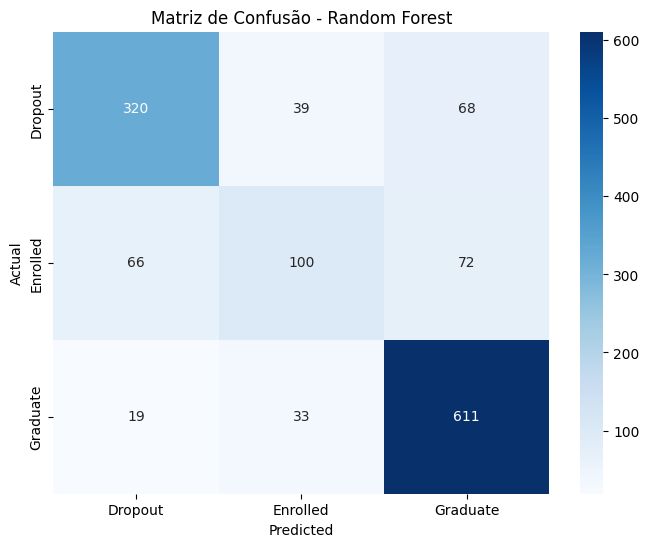

Random Forest - Test Accuracy: 0.7764
Random Forest - F1 Score: 0.7071


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/students_dropout_academic_success.csv')
df = pd.get_dummies(df, columns=['target'], dtype=int)
df['target'] = df[['target_Dropout', 'target_Enrolled', 'target_Graduate']].idxmax(axis=1)
df['target'] = df['target'].str.replace('target_', '')

X_num = df.select_dtypes(include=[np.number])

target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['target_num'] = df['target'].map(target_map)

X = df[['Application mode', 'Course', 'Previous qualification (grade)', "Mother's occupation",
        'Admission grade', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment',
        'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)',
        'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
        'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)',
        'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']]
y = df['target_num']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=42)

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Dropout', 'Enrolled', 'Graduate'], yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"Random Forest - Test Accuracy: {acc:.4f}")
print(f"Random Forest - F1 Score: {f1:.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Melhores parâmetros: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Acurácia no conjunto de teste: 0.8245
F1 Score no conjunto de teste: 0.8247


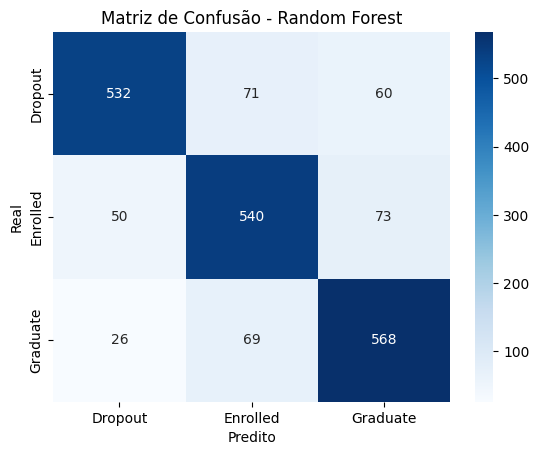

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

df = pd.read_csv('/content/students_dropout_academic_success.csv')

df = pd.get_dummies(df, columns=['target'], dtype=int)
df['target'] = df[['target_Dropout', 'target_Enrolled', 'target_Graduate']].idxmax(axis=1)
df['target'] = df['target'].str.replace('target_', '')

target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['target_num'] = df['target'].map(target_map)

X = df[['Application mode', 'Course', 'Previous qualification (grade)', "Mother's occupation",
        'Admission grade', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment',
        'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)',
        'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
        'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)',
        'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']]
y = df['target_num']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, stratify=y_res, random_state=42)

rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_

y_pred = best_rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Acurácia no conjunto de teste: {acc:.4f}")
print(f"F1 Score no conjunto de teste: {f1:.4f}")

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Dropout', 'Enrolled', 'Graduate'], yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()